In [ ]:
!pip install phe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 2.1 MB/s eta 0:00:00


Fingerprint Recognition System with Homomorphic Encryption
-----------------------------------------------------

Step 1: Template Enrollment
Upload fingerprint minutiae files (text files with x,y,angle per line)


Saving 32_6.txt to 32_6.txt
Saving 32_7.txt to 32_7.txt
Saving 32_8.txt to 32_8.txt
Saving 33_5.txt to 33_5.txt
Saving 33_6.txt to 33_6.txt

Enrolled template 32_6 with 54 minutiae points

Template 32_6 Encryption Details:
Public Key (n): 110570623357171255282847027059885761969279003588439807391918469423357623536552587126892929300718747503210700174368966045141278933661429592085804907255763867546799137015885848716326433729133691568633979842445179567921855631483323348337159251715454631112928101025266598567955531890890356718209649255996736504631
Number of minutiae points: 54

First few encrypted points (x, y, angle):

Point 1:
  x: 687662369063246220933520400013488380679644824291077147256038503493522547872863209210208617994224267565080534321775267134391821329267392063607001324636476864536223570435349260138010870136756269424872674804674682000952828527555940754346634044055332049347060740645980558794931058689603461630652947891230977835081526940905954877505468771363025576689500168619430347302

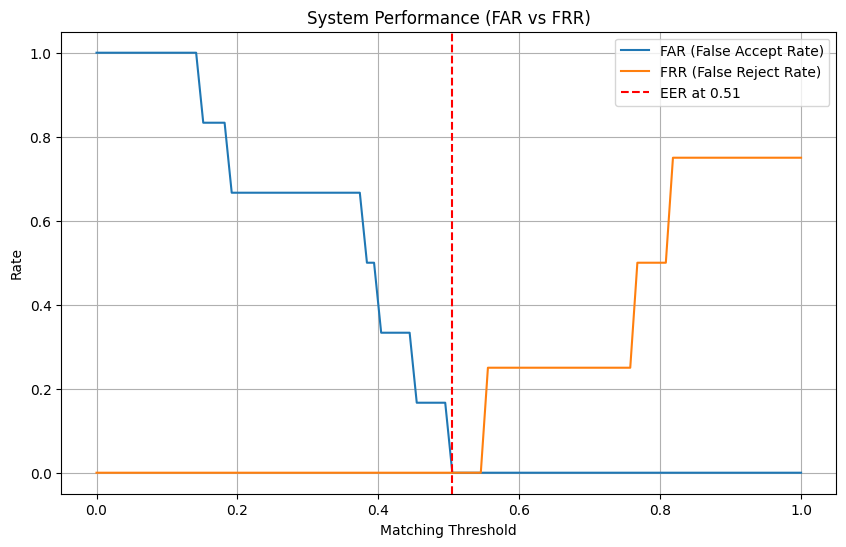


Performance Metrics:
Equal Error Rate (EER): 0.00%
Average Genuine Score: 79.15%
Average Imposter Score: 34.40%


In [ ]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.optimize import minimize
from phe import paillier
import matplotlib.pyplot as plt
from google.colab import files
import io

class FingerprintSystem:
    def __init__(self, key_size=2048):
        """Initialize the fingerprint system with Paillier homomorphic encryption"""
        self.public_key, self.private_key = paillier.generate_paillier_keypair(n_length=key_size)
        self.templates = {}
        self.scores = {'genuine': [], 'imposter': []}

    def read_minutiae(self, file_content):
        """Read minutiae points from file content"""
        try:
            data = np.loadtxt(io.StringIO(file_content), dtype=np.float64, usecols=(0, 1, 2))
        except (ValueError, IndexError):
            try:
                data = np.loadtxt(io.StringIO(file_content), dtype=np.float64)
                if data.shape[1] < 3:
                    raise ValueError("Minutiae file must have at least 3 columns (x, y, angle)")
            except Exception as e:
                raise ValueError(f"Error reading minutiae file: {str(e)}")

        if data.ndim == 1:
            if len(data) >= 3:
                data = data[:3]
                data = data.reshape(1, -1)
            else:
                raise ValueError("Each minutiae point must have at least x,y,angle")

        return data

    def encrypt_template(self, minutiae):
        """Encrypt minutiae template using Paillier homomorphic encryption"""
        encrypted = []
        for point in minutiae:
            encrypted_point = [
                self.public_key.encrypt(float(point[0])),
                self.public_key.encrypt(float(point[1])),
                self.public_key.encrypt(float(point[2]))
            ]
            encrypted.append(encrypted_point)
        return np.array(encrypted)

    def decrypt_template(self, encrypted_template):
        """Decrypt an encrypted minutiae template"""
        decrypted = []
        for point in encrypted_template:
            decrypted_point = [
                self.private_key.decrypt(point[0]),
                self.private_key.decrypt(point[1]),
                self.private_key.decrypt(point[2])
            ]
            decrypted.append(decrypted_point)
        return np.array(decrypted)

    def print_encrypted_template(self, encrypted_template, name="Template", limit=3):
        """Print the encrypted values in a human-readable format"""
        print(f"\n{name} Encryption Details:")
        print(f"Public Key (n): {self.public_key.n}")
        print(f"Number of minutiae points: {len(encrypted_template)}")
        print("\nFirst few encrypted points (x, y, angle):")

        for i, point in enumerate(encrypted_template[:limit]):
            print(f"\nPoint {i+1}:")
            print(f"  x: {point[0].ciphertext()} (hex: {hex(point[0].ciphertext())[:20]}...)")
            print(f"  y: {point[1].ciphertext()} (hex: {hex(point[1].ciphertext())[:20]}...)")
            print(f"  angle: {point[2].ciphertext()} (hex: {hex(point[2].ciphertext())[:20]}...)")

    def preprocess(self, minutiae):
        """Normalize minutiae points for comparison"""
        if len(minutiae) < 1:
            return minutiae

        processed = minutiae.copy()

        centroid = np.mean(processed[:, :2], axis=0)
        processed[:, :2] -= centroid

        std_dev = np.std(processed[:, :2])
        if std_dev > 1e-6:
            processed[:, :2] /= std_dev

        processed[:, 2] = (processed[:, 2] % 360) / 360

        return processed

    def align_templates(self, source, target):
        """Find optimal alignment between two minutiae sets"""
        if len(source) < 2 or len(target) < 2:
            return 0.0, 1.0

        def alignment_error(params):
            angle, tx, ty, scale = params
            rot_mat = np.array([
                [np.cos(angle), -np.sin(angle)],
                [np.sin(angle), np.cos(angle)]
            ])
            transformed = scale * np.dot(source[:, :2], rot_mat) + np.array([tx, ty])
            tree = cKDTree(target[:, :2])
            distances, _ = tree.query(transformed, k=1)
            return np.mean(distances)

        initial_params = [0.0, 0.0, 0.0, 1.0]

        bounds = [
            (-np.pi, np.pi),
            (-2.0, 2.0),
            (-2.0, 2.0),
            (0.5, 1.5)
        ]

        result = minimize(
            alignment_error,
            initial_params,
            bounds=bounds,
            method='L-BFGS-B',
            options={'maxiter': 100}
        )

        return result.x[0], result.x[3]

    def secure_match(self, encrypted_query, template_id, dist_thresh=0.5, angle_thresh=0.1):
        """Perform secure matching between encrypted query and stored template"""
        stored_encrypted = self.templates.get(template_id)
        if stored_encrypted is None:
            return 0.0

        query = self.decrypt_template(encrypted_query)
        target = self.decrypt_template(stored_encrypted)

        query_proc = self.preprocess(query)
        target_proc = self.preprocess(target)

        angle, scale = self.align_templates(query_proc, target_proc)

        rot_mat = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle), np.cos(angle)]
        ])

        transformed = scale * np.dot(query_proc[:, :2], rot_mat)

        tree = cKDTree(target_proc[:, :2])

        dists, indices = tree.query(transformed)

        matches = 0
        for i, (dist, idx) in enumerate(zip(dists, indices)):
            if dist < dist_thresh:
                angle_diff = abs((query_proc[i, 2] + angle/(2*np.pi)) % 1.0 - target_proc[idx, 2])
                angle_diff = min(angle_diff, 1 - angle_diff)
                if angle_diff < angle_thresh:
                    matches += 1

        return matches / min(len(query_proc), len(target_proc))

    def evaluate_system(self):
        """Evaluate system performance using FAR/FRR metrics"""
        genuine_scores = np.array(self.scores['genuine'])
        imposter_scores = np.array(self.scores['imposter']) if self.scores['imposter'] else np.array([])

        metrics = {
            'FAR': [],
            'FRR': [],
            'EER': np.nan,
            'EER_Threshold': np.nan,
            'Genuine_Mean': np.mean(genuine_scores) if len(genuine_scores) > 0 else np.nan,
            'Imposter_Mean': np.mean(imposter_scores) if len(imposter_scores) > 0 else np.nan
        }

        if len(imposter_scores) > 0:
            thresholds = np.linspace(0, 1, 100)
            far = []
            frr = []

            for th in thresholds:
                far.append(np.mean(imposter_scores >= th))
                frr.append(np.mean(genuine_scores < th))

            metrics['FAR'] = far
            metrics['FRR'] = frr

            diff = np.abs(np.array(far) - np.array(frr))
            eer_index = np.argmin(diff)
            metrics['EER'] = (far[eer_index] + frr[eer_index]) / 2
            metrics['EER_Threshold'] = thresholds[eer_index]

            plt.figure(figsize=(10, 6))
            plt.plot(thresholds, far, label='FAR (False Accept Rate)')
            plt.plot(thresholds, frr, label='FRR (False Reject Rate)')
            plt.axvline(x=metrics['EER_Threshold'], color='r', linestyle='--',
                       label=f'EER at {metrics["EER_Threshold"]:.2f}')
            plt.xlabel('Matching Threshold')
            plt.ylabel('Rate')
            plt.title('System Performance (FAR vs FRR)')
            plt.legend()
            plt.grid(True)
            plt.show()

        return metrics

def main():
    """Main function to demonstrate the fingerprint system"""
    print("Fingerprint Recognition System with Homomorphic Encryption")
    print("-----------------------------------------------------")

    system = FingerprintSystem(key_size=1024)

    print("\nStep 1: Template Enrollment")
    print("Upload fingerprint minutiae files (text files with x,y,angle per line)")

    uploaded = files.upload()
    for filename, content in uploaded.items():
        template_id = filename.split('.')[0]
        try:
            minutiae = system.read_minutiae(content.decode('utf-8'))
            encrypted = system.encrypt_template(minutiae)
            system.templates[template_id] = encrypted
            print(f"\nEnrolled template {template_id} with {len(minutiae)} minutiae points")

            system.print_encrypted_template(encrypted, name=f"Template {template_id}")

        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")

    if not system.templates:
        print("No valid templates enrolled. Exiting.")
        return

    print("\nStep 2: Matching")
    template_ids = list(system.templates.keys())

    for i in range(len(template_ids)):
        for j in range(i, len(template_ids)):
            id1 = template_ids[i]
            id2 = template_ids[j]

            if i == j:
                continue

            enc1 = system.templates[id1]
            enc2 = system.templates[id2]

            score1 = system.secure_match(enc1, id2)
            score2 = system.secure_match(enc2, id1)
            score = max(score1, score2)

            user1 = id1.split('_')[0]
            user2 = id2.split('_')[0]

            if user1 == user2:
                system.scores['genuine'].append(score)
                print(f"Genuine match: {id1} vs {id2} -> Score: {score:.2f}")
            else:
                system.scores['imposter'].append(score)
                print(f"Imposter match: {id1} vs {id2} -> Score: {score:.2f}")

    print("\nStep 3: System Evaluation")
    metrics = system.evaluate_system()

    print("\nPerformance Metrics:")
    print(f"Equal Error Rate (EER): {metrics['EER']:.2%}") if not np.isnan(metrics['EER']) else print("EER: Not enough data")
    print(f"Average Genuine Score: {metrics['Genuine_Mean']:.2%}") if not np.isnan(metrics['Genuine_Mean']) else print("No genuine matches")
    print(f"Average Imposter Score: {metrics['Imposter_Mean']:.2%}") if not np.isnan(metrics['Imposter_Mean']) else print("No imposter matches")

if __name__ == "__main__":
    main()